In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [35]:
df = pd.read_csv("pod_gpu_duty_cycle_anon.csv")


# Convert columns to numbers
df["timestamp_anon"] = pd.to_numeric(df["timestamp_anon"], errors="coerce")
df["value"] = pd.to_numeric(df["value"], errors="coerce")

# Remove rows with missing values
df = df.dropna(subset=["timestamp_anon", "value", "container_ip"])

# Sort by time
df = df.sort_values("timestamp_anon")

#look at all timestamp_anon column, find the minimum and store in start_time
start_time = df["timestamp_anon"].min()

#subtract first timestamp from every row to get 
df["elapsed_seconds"] = df["timestamp_anon"] - start_time

# Convert seconds to hours
df["elapsed_hours"] = df["elapsed_seconds"] / 3600

#MAKE 1 minute bins
BIN_SIZE = 60  

df["time_bin"] = (df["elapsed_seconds"] // BIN_SIZE) * BIN_SIZE

# convert 1 minute bins into hours
df["time_bin_hours"] = df["time_bin"] / 3600

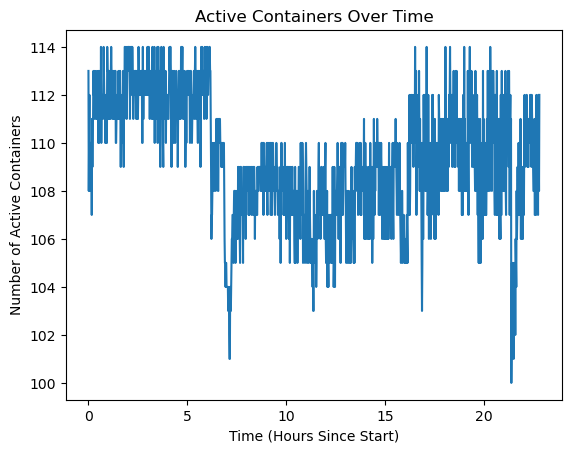

In [36]:
#For each time bin (each minute), count how many different container_ip values appeared
container_count = df.groupby("time_bin_hours")["container_ip"].nunique()

# Convert to a normal DataFrame
container_count = container_count.reset_index()

# Plot
plt.figure()
plt.plot(container_count["time_bin_hours"],
         container_count["container_ip"])

plt.xlabel("Time (Hours Since Start)")
plt.ylabel("Number of Active Containers")
plt.title("Active Containers Over Time")
plt.show()

In [41]:
import matplotlib.animation as animation
import matplotlib.pyplot as plt

# average GPU utilization per container across all time bins
avg_usage = df.groupby("container_ip")["value"].mean()

# sort containers from highest to lowest average GPU usage
avg_usage = avg_usage.sort_values(ascending=False)

# select the top 5 container IPs with the highest average GPU usage
top_containers = avg_usage.head(5).index

# average GPU usage per time bin per container
grouped = df.groupby(["time_bin_hours", "container_ip"])["value"].mean()

grouped = grouped.reset_index()

# keep only the rows belonging to the top 5 containers
filtered = grouped[grouped["container_ip"].isin(top_containers)]

fig, ax = plt.subplots(figsize=(12, 6))

# Define the animation function
def animate(i):
    # clear the previous frame's plot
    ax.clear()
    
    # Plot containers one by one, adding one new line per frame
    for container in top_containers[:i+1]:
        
        # filter rows for this specific container
        container_data = filtered[filtered["container_ip"] == container]
        
        # plot this container's GPU utilization over time
        ax.plot(container_data["time_bin_hours"],
                container_data["value"],
                label=str(container))
    
    ax.set_xlim(0, 23)
    ax.set_xlabel("Time (Hours Since Start)")
    ax.set_ylabel("Average GPU Utilization (%)")
    ax.set_title("Top 5 Containers GPU Utilization Over Time")
    ax.legend(loc="upper right")

# Create the animation :  one frame per container, 800ms between frames
ani = animation.FuncAnimation(
    fig,          
    animate,      
    frames=len(top_containers),
    interval=800, 
    repeat=False  
)

# save as a GIF using the pillow library
ani.save("gpu_utilization.gif", writer="pillow", fps=1)

plt.close()

# confirm that the file has been saved
print("Saved as gpu_utilization.gif")

Saved as gpu_utilization.gif


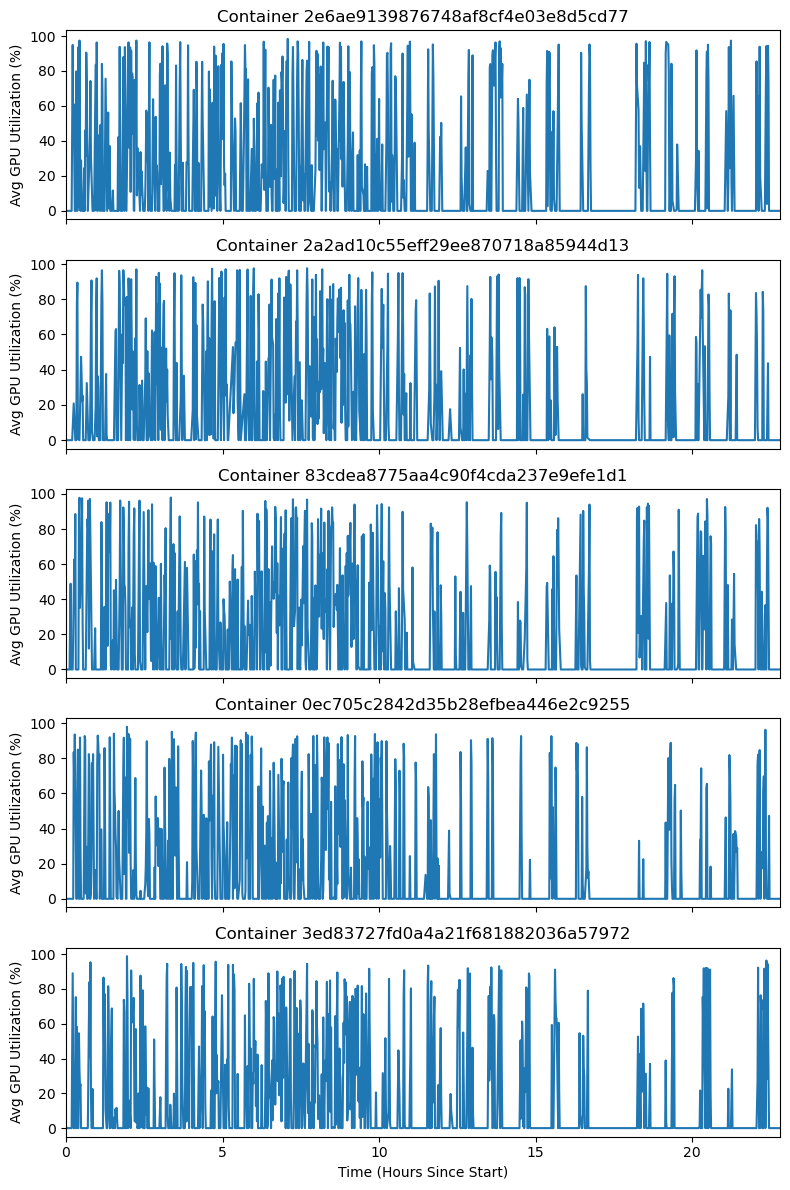

In [ ]:
avg_usage = df.groupby("container_ip")["value"].mean()

# Sort from highest to lowest
avg_usage = avg_usage.sort_values(ascending=False)

# Get the top 5 container IDs since plotting all 143 unique containers is too crowded on a graph
top_containers = avg_usage.head(5).index

#Compute average GPU usage per time bin per container
grouped = df.groupby(["time_bin_hours", "container_ip"])["value"].mean()
grouped = grouped.reset_index()

#keep only the top 5 containers 
filtered = grouped[grouped["container_ip"].isin(top_containers)]

# Create 5 vertical subplots
fig, axes = plt.subplots(5, 1, figsize=(8, 12), sharex=True)

# Get full time range
x_min = grouped["time_bin_hours"].min()
x_max = grouped["time_bin_hours"].max()

for i, container in enumerate(top_containers):
    
    # Only the rows corresponding to this container
    container_data = filtered[filtered["container_ip"] == container]
    
    #Plot GPU utilization over time for this container
    axes[i].plot(container_data["time_bin_hours"],
                 container_data["value"])
    
    axes[i].set_title(f"Container {container}")
    axes[i].set_ylabel("Avg GPU Utilization (%)")
    # Same horizontal range of 0-20 hours
    axes[i].set_xlim(x_min, x_max)  

# Only label the bottom subplot to avoid repeating the same label five times
axes[-1].set_xlabel("Time (Hours Since Start)")

plt.tight_layout()
plt.show()

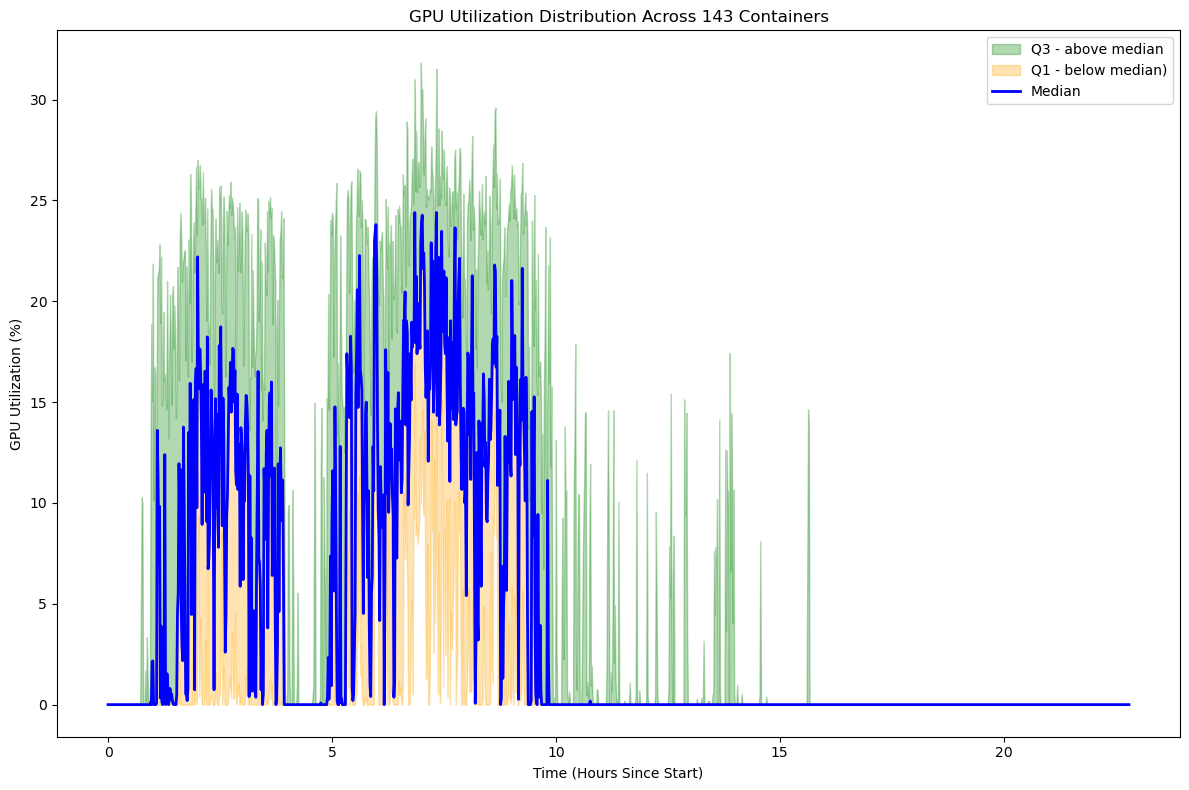

In [ ]:
grouped = df.groupby(["time_bin_hours", "container_ip"])["value"].mean()
grouped = grouped.reset_index()

# Summary statistics across containers at each time point
stats = grouped.groupby("time_bin_hours")["value"].agg(
    median="median",
    q1=lambda x: x.quantile(0.25),
    q3=lambda x: x.quantile(0.75)
)
stats = stats.reset_index()

plt.figure(figsize=(12, 8))

# Shade Q3 band above the median
plt.fill_between(
    stats["time_bin_hours"],
    stats["median"],
    stats["q3"],
    alpha=0.3,
    color="green",
    label="Q3 - above median"
)

# Shade Q1 band below the median
plt.fill_between(
    stats["time_bin_hours"],
    stats["q1"],
    stats["median"],
    alpha=0.3,
    color="orange",
    label="Q1 - below median"
)

# Plot the median curve on top
plt.plot(stats["time_bin_hours"], stats["median"], color="blue", linewidth=2, label="Median")

plt.xlabel("Time (Hours Since Start)")
plt.ylabel("GPU Utilization (%)")
plt.title("GPU Utilization Distribution Across 143 Containers")
plt.legend()
plt.tight_layout()
plt.show()

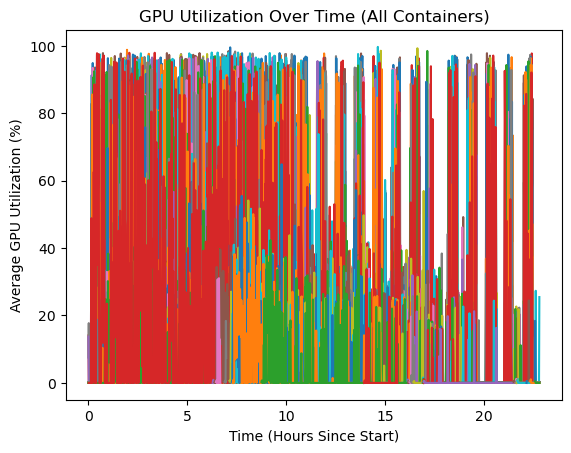

In [8]:
#Compute average GPU usage per time bin per container
grouped = df.groupby(["time_bin_hours", "container_ip"])["value"].mean()
grouped = grouped.reset_index()

plt.figure()

# Loop through every container and plot time_bin_hours vs value

for container in grouped["container_ip"].unique():
    container_data = grouped[grouped["container_ip"] == container]
    plt.plot(container_data["time_bin_hours"],
             container_data["value"])

plt.xlabel("Time (Hours Since Start)")
plt.ylabel("Average GPU Utilization (%)")
plt.title("GPU Utilization Over Time (All Containers)")
plt.show()

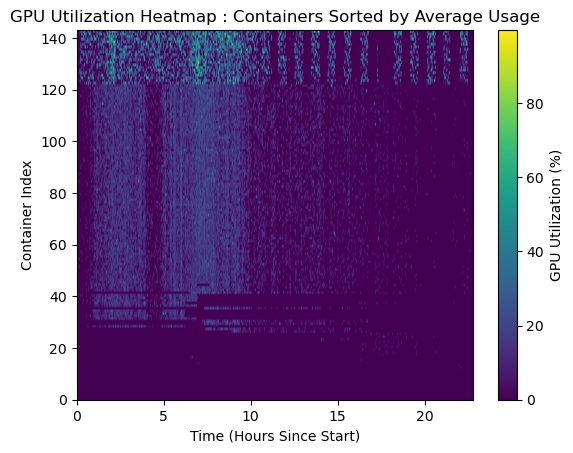

In [42]:
grouped = df.groupby(["time_bin_hours", "container_ip"])["value"].mean()
grouped = grouped.reset_index()


# make matrix form : rows - containers, columns - time bins, values = average gpu usage
heatmap_data = grouped.pivot(
    index="container_ip",
    columns="time_bin_hours",
    values="value"
)

# replace missing values with 0
heatmap_data = heatmap_data.fillna(0)

# compute average utilization per container across all time bins
container_avg = heatmap_data.mean(axis=1)

# sort containers by average utilization (descending)
sorted_containers = container_avg.sort_values(ascending=False).index

# reorder heatmap rows
heatmap_data = heatmap_data.loc[sorted_containers]
# create figure
plt.figure()

# show matrix as heatmap
plt.imshow(
    heatmap_data.values,
    aspect='auto',
    extent=[
        heatmap_data.columns.min(),
        heatmap_data.columns.max(),
        0,
        len(heatmap_data.index)
    ]
)

# add color bar
plt.colorbar(label="GPU Utilization (%)")

# label axes
plt.xlabel("Time (Hours Since Start)")
plt.ylabel("Container Index")

# add title
plt.title("GPU Utilization Heatmap : Containers Sorted by Average Usage")

plt.show()

In [17]:
print(df["value"].min())
print(df["value"].max())

0.0
99.66666666666669
